In [1]:
import numpy as np
import pandas as pd
import glob
import os
import random
import matplotlib.pyplot as plt

In [2]:
## grab files
from logging import root

root_directory = r'C:\Users\Leila\VULocal\Projects\fMRI\fmrimedi\task\MEDTUN_task'
directory = 'optseq2_design_pilot2-v5'
# pattern = 'tr-200_min-3_nsearch-1000*.par'
pattern = 'design_11cond_focb_pilot2-v5*.par'
texture_id = [i for i in range(160)] # there are 160 density-4 snakes
target_directory = 'trial_sequences'
# define mapping frames to ms
# frames_ms_mapping = {0 : 0, 2 : 17, 4 : 33, 8 : 67, 16 : 134, 32 : 267, 64 : 533}
ms = [0, 50, 75, 100, 150, 225, 325, 475, 700, 1025, 1500]; # [0, 25,50,75,100,175,275,475,750,1225,2000]
frames = [0, 6, 9, 12, 18, 27, 39, 57, 84, 123, 180]; # [0,3,6,9,12,21,33,57,90,147,240]
frames_ms_mapping = {key: val for key, val in zip(frames, ms)}

dur_idx_frames_mapping = {idx : frame for idx, frame in zip(range(11), frames)} #[0] + frames

files = glob.glob(os.path.join(root_directory, directory, pattern))
files.sort()

plot = False
if plot:
    fig, axs = plt.subplots(3,5, figsize=(15,9))


In [3]:

# print(files)
for j, file in enumerate(files):

    with open(file, 'r') as f:
        lines = f.readlines()

    rows = []
    for line in lines:
        split_line = line.split(' ')
        vals = [val.strip() for val in split_line if (val != '') & (val != '\n')]
        for i in range(len(vals)-1):
            vals[i] = np.round(float(vals[i]), 2)
        
        # adding 0s to itis
        if vals[-1] == 'NULL':
            rows[-1][2] = np.round(rows[-1][2] + vals[2], 2)
            # uncomment to debug
    #         rows.append(vals)
        
        else:
            rows.append(vals)
    print(rows)
    iti_df = pd.DataFrame(rows, columns = ['time', 'id', 'iti_s', 'unknown', 'type'])
    iti_df['time'] = iti_df['time'].astype(float)
    iti_df['iti_s'] = iti_df['iti_s'].astype(float)
    iti_df['iti_TR'] = np.round(iti_df['iti_s']/.9).astype(int)
    iti_df['iti_TR_cum'] = np.cumsum(iti_df['iti_TR'])
    iti_df['cond_frames'] = [dur_idx_frames_mapping[int(val.split('_')[1])] for val in iti_df['type']]
    iti_df['type'] = [val.split('_')[0] for val in iti_df['type']]
    iti_df = iti_df.drop(['id', 'unknown'], axis = 1)
    iti_df['cond_ms'] = [frames_ms_mapping[val] for val in iti_df['cond_frames']]
    iti_df['phase_0_ms'] = [2000] * len(iti_df)
    iti_df['phase_0_frames'] = [240] * len(iti_df)
    iti_df['phase_1_ms'] = iti_df['iti_s'] - 2.0
    iti_df['phase_1_frames'] = (iti_df['phase_1_ms'] * 120).astype(int)
    
    
    random.shuffle(texture_id)
    iti_df['texture_id'] = texture_id[:len(iti_df)]

    # check
    print(iti_df.iti_TR_cum.iloc[-1])
    if plot:

        n, bins, _ = axs.flatten()[j].hist(iti_df['iti_s'])
        if j % 5 ==0:
            axs.flatten()[j].set_ylabel("counts")
        if j >= 10:
            axs.flatten()[j].set_xlabel("ITI [s]")
        
    # dot product of histogram
    # print(iti_df.iti_TR.value_counts().values @ iti_df.iti_TR.value_counts().keys().to_numpy())    
    # print(n.shape, bins.shape)
    # print(n, bins)
    
    
    # save
    try:
        os.mkdir(target_directory)
    except FileExistsError:
        pass
    path = os.path.join(target_directory, f'design_11cond_focb_pilot2-v5_{file.split("-")[-1].split(".")[0]}.csv')
    iti_df.to_csv(path, index = False)
# plt.savefig('iti_hist_new_seq.png', transparent = False)

[[0.0, 8.0, 4.5, 1.0, 'dur_7'], [4.5, 3.0, 4.5, 1.0, 'dur_2'], [9.0, 2.0, 4.5, 1.0, 'dur_1'], [13.5, 7.0, 4.5, 1.0, 'dur_6'], [18.0, 5.0, 6.3, 1.0, 'dur_4'], [24.3, 5.0, 4.5, 1.0, 'dur_4'], [28.8, 11.0, 4.5, 1.0, 'dur_10'], [33.3, 8.0, 6.3, 1.0, 'dur_7'], [39.6, 1.0, 4.5, 1.0, 'dur_0'], [44.1, 1.0, 4.5, 1.0, 'dur_0'], [48.6, 9.0, 4.5, 1.0, 'dur_8'], [53.1, 2.0, 7.2, 1.0, 'dur_1'], [60.3, 2.0, 6.3, 1.0, 'dur_1'], [66.6, 9.0, 5.4, 1.0, 'dur_8'], [72.0, 6.0, 7.2, 1.0, 'dur_5'], [79.2, 10.0, 6.3, 1.0, 'dur_9'], [85.5, 4.0, 4.5, 1.0, 'dur_3'], [90.0, 4.0, 4.5, 1.0, 'dur_3'], [94.5, 6.0, 5.4, 1.0, 'dur_5'], [99.9, 1.0, 4.5, 1.0, 'dur_0'], [104.4, 3.0, 7.2, 1.0, 'dur_2'], [111.6, 4.0, 8.1, 1.0, 'dur_3'], [119.7, 1.0, 4.5, 1.0, 'dur_0'], [124.2, 10.0, 4.5, 1.0, 'dur_9'], [128.7, 2.0, 6.3, 1.0, 'dur_1'], [135.0, 6.0, 5.4, 1.0, 'dur_5'], [140.4, 5.0, 6.3, 1.0, 'dur_4'], [146.7, 7.0, 4.5, 1.0, 'dur_6'], [151.2, 7.0, 4.5, 1.0, 'dur_6'], [155.7, 6.0, 5.4, 1.0, 'dur_5'], [161.1, 3.0, 4.5, 1.0, 'dur_

In [4]:
iti_df

,time,iti_s,type,iti_TR,iti_TR_cum,cond_frames,cond_ms,phase_0_ms,phase_0_frames,phase_1_ms,phase_1_frames,texture_id
0,0.0,4.5,dur,5,5,27,225,2000,240,2.5,300,30
1,4.5,5.4,dur,6,11,12,100,2000,240,3.4,408,57
2,9.9,4.5,dur,5,16,123,1025,2000,240,2.5,300,149
3,14.4,10.8,dur,12,28,9,75,2000,240,8.8,1056,91
4,25.2,4.5,dur,5,33,6,50,2000,240,2.5,300,44
5,29.7,4.5,dur,5,38,9,75,2000,240,2.5,300,6
6,34.2,4.5,dur,5,43,39,325,2000,240,2.5,300,144
7,38.7,9.0,dur,10,53,57,475,2000,240,7.0,840,148
8,47.7,4.5,dur,5,58,18,150,2000,240,2.5,300,98
9,52.2,4.5,dur,5,63,84,700,2000,240,2.5,300,68


Note for future optseq2 endeavours: try to make sure min of 2 or 3 trs either by increasing duration to that or by not allowing 0 as an option for NULL in between

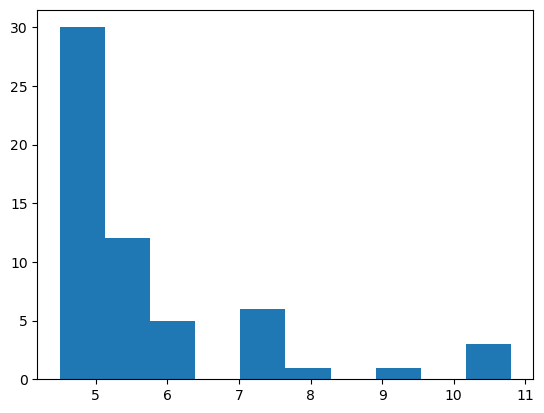

iti_s
4.5     30
5.4     12
7.2      6
6.3      5
10.8     3
9.0      1
8.1      1
Name: count, dtype: int64

In [5]:
import matplotlib.pyplot as plt
plt.hist(iti_df['iti_s'])
plt.show()
iti_df['iti_s'].value_counts()